In [4]:
# STEP 1: Renaming features, adding percentiles, and computing sequence length
import pandas as pd
import numpy as np
import ast


# === Load the dataset ===
data_path = "/home/goel107/NCEMS/ANALYSIS/07_15_2025/5-s288c-nodes-final-per-node.pkl"
df = pd.read_pickle(data_path)

# Rename columns to replace spaces with underscores for easier referencing
df = df.rename(columns={
    "Mean molecules per cell": "Mean_molecules_per_cell",
    "Median molecules per cell": "Median_molecules_per_cell",
    "t1/2 (min)": "t1/2_min"
})

# === Select relevant columns ===
selected_columns = df[[ 
    'node', '_wkshell', 
    'degree_centrality', 'betweenness_centrality', 'eigenvector_centrality', 'closeness_centrality',
    'load_centrality', 'pagerank', 'information_centrality',
    'Y2H_degree_centrality', 'Y2H_betweenness_centrality', 'Y2H_eigenvector_centrality',
    'Y2H_closeness_centrality', 'Y2H_load_centrality', 'Y2H_pagerank', 'Y2H_information_centrality',
    'signalP_trimmed_sequence',
    'Rosetta_total_score', 'FoldX_total_energy', 'Ghosh-Dill-dG', 'cagiada-dG',
    'log2_TE', 't1/2_min', 'Mean_molecules_per_cell', 'Median_molecules_per_cell',
    'essential', 'Pfam_Ndomains', 'in_complex',
    'disorder_fraction', 'IDR_count', 'mean_plddt', 'interacting_chaperones', 'sequence', 'structure_exists', 'sequence_matches_structure',
    'is_disordered_0.05', 'is_disordered_0.10', 'is_disordered_0.15', 'is_disordered_0.20', 'is_disordered_0.25', 'is_disordered_0.30', 'is_disordered_0.35', 
    'is_disordered_0.40', 'is_disordered_0.45', 'is_disordered_0.50', 'is_disordered_0.55', 'is_disordered_0.60', 'is_disordered_0.65', 'is_disordered_0.70', 
    'is_disordered_0.75', 'is_disordered_0.80', 'is_disordered_0.85', 'is_disordered_0.90', 'is_disordered_0.95', 'is_disordered_1.00'    
]].copy()

# Multiply 'cagiada-dG' by -1 (flip sign)
selected_columns['cagiada-dG'] = pd.to_numeric(selected_columns['cagiada-dG'], errors='coerce') * -1

# Replace infinite values with NaN to allow proper cleaning
selected_columns.replace([np.inf, -np.inf], np.nan, inplace=True)

# Fix Pfam_Ndomains: replace empty/NaN with 0
selected_columns['Pfam_Ndomains'] = selected_columns['Pfam_Ndomains'].fillna(0).astype(int)

# === STEP 3: DERIVED FEATURES ===
selected_columns['Length'] = selected_columns['signalP_trimmed_sequence'].fillna('').apply(len)

# Add percentile columns for all centrality metrics
ms_centrality_cols = [
    'degree_centrality', 'betweenness_centrality', 'eigenvector_centrality',
    'closeness_centrality', 'load_centrality', 'pagerank', 'information_centrality'
]
y2h_centrality_cols = [
    'Y2H_degree_centrality', 'Y2H_betweenness_centrality', 'Y2H_eigenvector_centrality',
    'Y2H_closeness_centrality', 'Y2H_load_centrality', 'Y2H_pagerank', 'Y2H_information_centrality'
]

# Rename MS columns
ms_rename_map = {col: "MS_" + col for col in ms_centrality_cols}
selected_columns.rename(columns=ms_rename_map, inplace=True)

# Add percentiles for MS-based metrics
for col in ms_centrality_cols:
    ms_col = "MS_" + col
    selected_columns[f"{ms_col}_percentile"] = selected_columns[ms_col].rank(pct=True) * 100

# Add percentiles for Y2H-based metrics
for col in y2h_centrality_cols:
    selected_columns[f"{col}_percentile"] = selected_columns[col].rank(pct=True) * 100

# === STEP 4: ONE HOT ENCODING FOR CHAPERONES ===
def fix_list(val):
    if isinstance(val, list):
        return val
    elif isinstance(val, str):
        try:
            return ast.literal_eval(val)
        except:
            return []
    elif pd.isnull(val):
        return []
    else:
        return []

selected_columns['interacting_chaperones'] = selected_columns['interacting_chaperones'].apply(fix_list)

def chaperone_category(row):
    node = row['node']
    chaps = row['interacting_chaperones']
    if not chaps or chaps == []:
        return 'protein_is_neither_chaperone_nor_interacts'
    elif node in chaps:
        return 'protein_is_chaperone'
    else:
        return 'protein_interacts_with_chaperone'

selected_columns['chaperone_category'] = selected_columns.apply(chaperone_category, axis=1)
selected_columns['is_chaperone'] = (selected_columns['chaperone_category'] == 'protein_is_chaperone').astype(int)
selected_columns['interacts_with_chaperone'] = (selected_columns['chaperone_category'] == 'protein_interacts_with_chaperone').astype(int)
selected_columns['neither_chaperone_nor_interacts'] = (selected_columns['chaperone_category'] == 'protein_is_neither_chaperone_nor_interacts').astype(int)

# === STEP 5: Match seq and structure nodes ===
selected_columns.info()
selected_columns = selected_columns[~selected_columns["sequence"].isna()]
print (f"Number of nodes with sequence information: {selected_columns.shape[0]}")


    

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3927 entries, 0 to 3926
Data columns (total 74 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   node                                   3927 non-null   object 
 1   _wkshell                               3927 non-null   int64  
 2   MS_degree_centrality                   3927 non-null   float64
 3   MS_betweenness_centrality              3927 non-null   float64
 4   MS_eigenvector_centrality              3927 non-null   float64
 5   MS_closeness_centrality                3927 non-null   float64
 6   MS_load_centrality                     3927 non-null   float64
 7   MS_pagerank                            3927 non-null   float64
 8   MS_information_centrality              3927 non-null   float64
 9   Y2H_degree_centrality                  1465 non-null   float64
 10  Y2H_betweenness_centrality             1465 non-null   float64
 11  Y2H_

In [6]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import pandas as pd

# Select only the 'essential' feature
X = selected_columns[['essential']].copy()

# No log transform since 'Mean_molecules_per_cell' is not included

# Binary columns (only essential here)
binary_cols = ['essential']

# No continuous columns
cont_cols = []

# Replace known non-numeric strings with NaN
X.replace('n.d.', np.nan, inplace=True)

# Convert all columns to numeric forcing errors to NaN (should be binary 0/1 but safe to keep)
for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors='coerce')

# Prepare imputer and scaler
imputer = SimpleImputer(strategy='mean')
scaler = StandardScaler()

# Only impute and scale continuous columns if any exist
if cont_cols:
    X_cont = pd.DataFrame(imputer.fit_transform(X[cont_cols]), columns=cont_cols, index=X.index)
    X_cont = pd.DataFrame(scaler.fit_transform(X_cont), columns=cont_cols, index=X.index)
else:
    # No continuous columns — create empty DataFrame to concat later
    X_cont = pd.DataFrame(index=X.index)

# Combine continuous (scaled) and binary columns (untouched)
X_processed = pd.concat([X_cont, X[binary_cols]], axis=1)

print("Preprocessing done. Here are means and stds of scaled features:")
if cont_cols:
    print(X_processed[cont_cols].mean())  # close to 0
    print(X_processed[cont_cols].std())   # close to 1
else:
    print("No continuous columns to scale.")

# Now X_processed is ready to be used in your logistic regression model.


Preprocessing done. Here are means and stds of scaled features:
No continuous columns to scale.


In [7]:
# Create binary target: 1 if in top 10%, else 0
selected_columns['target_value'] = (selected_columns['MS_degree_centrality_percentile'] >= 90).astype(int)

# Check counts of each class (0 or 1)
class_counts = selected_columns['target_value'].value_counts()
print(class_counts)


0    3491
1     385
Name: target_value, dtype: int64


In [8]:
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold

# Set random seed for reproducibility
random_seed = 1

# Number of folds for cross-validation
Nfolds = 5

# Define feature matrix X and target vector y
# Use your preprocessed features here:
X = X_processed.copy()

# Target variable created earlier
y = selected_columns['target_value'].copy()

# Make sure X and y have matching indexes and drop any rows with missing values if any
mask = (~y.isna()) & (~X.isna().any(axis=1))
X = X.loc[mask]
y = y.loc[mask]

# Reserve 20% of data for final holdout testing
X_train, X_holdout, y_train, y_holdout = train_test_split(
    X, y, test_size=0.2, random_state=random_seed, stratify=y
)

# Set up stratified k-fold cross-validation on training data
kf = StratifiedKFold(n_splits=Nfolds, shuffle=True, random_state=random_seed)

# Set of lambda (alpha) values for LASSO regularization hyperparameter tuning
lambda_vals = np.logspace(-1, 4, 6)

# Print shapes to confirm splits
print(f"Training data shape: {X_train.shape}, Training labels shape: {y_train.shape}")
print(f"Holdout data shape: {X_holdout.shape}, Holdout labels shape: {y_holdout.shape}")
print(f"Lambda values for tuning: {lambda_vals}")


Training data shape: (3100, 1), Training labels shape: (3100,)
Holdout data shape: (776, 1), Holdout labels shape: (776,)
Lambda values for tuning: [1.e-01 1.e+00 1.e+01 1.e+02 1.e+03 1.e+04]


In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate
from datetime import datetime

# Save the start time of the process
startTime = datetime.now()

# Maximum iterations for solver convergence
max_iter = 10000

# Dictionary to store cross-validation results for each lambda
results_dict = {}

print("Running cross-validation for lambda tuning...")

# Loop over all lambda values
for lambda_val in lambda_vals:
    # Setup logistic regression with L1 penalty (LASSO)
    # Note: C is inverse of regularization strength lambda
    model = LogisticRegression(
        penalty="l1",
        solver="saga",
        max_iter=max_iter,
        C=1 / lambda_val,
        random_state=1,
        class_weight='balanced'  # handles class imbalance during training
    )
    
    # Run cross-validation with stratified folds
    cv_results = cross_validate(
        model,
        X_train,
        y_train,
        cv=kf,
        scoring=['balanced_accuracy', 'roc_auc'],
        return_estimator=True,
        n_jobs=-1
    )
    
    # Store results
    results_dict[lambda_val] = cv_results
    
    # Calculate and print elapsed time
    elapsed_sec = (datetime.now() - startTime).total_seconds()
    print(f"Lambda: {lambda_val:10.4f} | Elapsed time: {elapsed_sec:10.2f} seconds")


Running cross-validation for lambda tuning...


/home/goel107/.conda/envs/ml_class/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/goel107/.conda/envs/ml_class/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Lambda:     0.1000 | Elapsed time:       2.96 seconds


/home/goel107/.conda/envs/ml_class/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Lambda:     1.0000 | Elapsed time:       5.29 seconds


/home/goel107/.conda/envs/ml_class/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/goel107/.conda/envs/ml_class/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Lambda:    10.0000 | Elapsed time:       7.59 seconds
Lambda:   100.0000 | Elapsed time:       8.09 seconds
Lambda:  1000.0000 | Elapsed time:       8.60 seconds
Lambda: 10000.0000 | Elapsed time:       9.12 seconds


Lambda      Balanced Acc (mean ± std)  AUROC (mean ± std)            Non-zero Coeffs (mean ± std)
    0.1000	0.550 ± 0.049		0.580 ± 0.021		       1.0 ±        0.0
    1.0000	0.580 ± 0.021		0.580 ± 0.021		       1.0 ±        0.0
   10.0000	0.532 ± 0.048		0.563 ± 0.041		       0.8 ±        0.4
  100.0000	0.500 ± 0.000		0.500 ± 0.000		       0.0 ±        0.0
 1000.0000	0.500 ± 0.000		0.500 ± 0.000		       0.0 ±        0.0
10000.0000	0.500 ± 0.000		0.500 ± 0.000		       0.0 ±        0.0


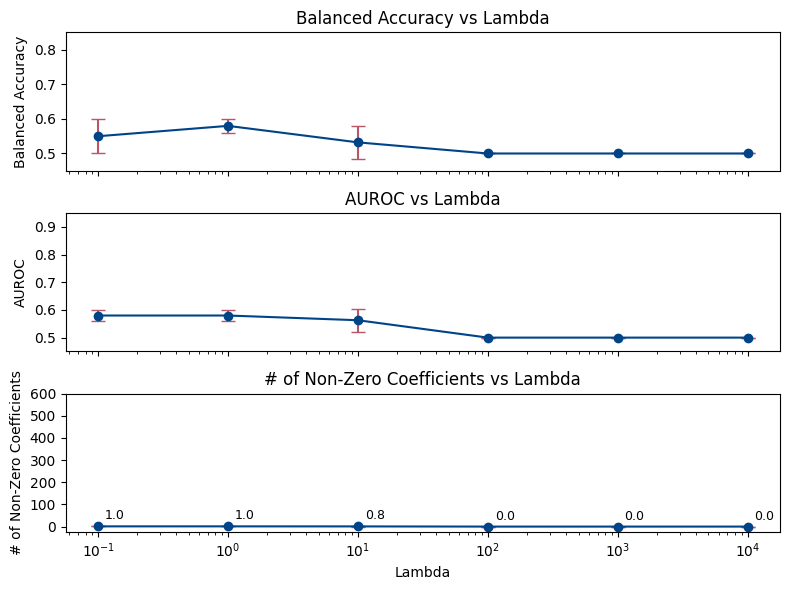

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Sort lambda values
lambda_vals = sorted(results_dict.keys())

# Initialize lists to store aggregated metric means and stds
bal_acc_means, bal_acc_stds = [], []
auroc_means, auroc_stds = [], []
nonzero_means, nonzero_stds = [], []

# Loop over each lambda and compute metrics
for lambda_val in lambda_vals:
    cv_results = results_dict[lambda_val]
    
    # Extract balanced accuracy and AUROC scores
    test_bal_acc = cv_results['test_balanced_accuracy']
    test_roc_auc = cv_results['test_roc_auc']
    
    # Compute mean and std
    mean_bal_acc = np.mean(test_bal_acc)
    std_bal_acc = np.std(test_bal_acc, ddof=1)
    mean_roc_auc = np.mean(test_roc_auc)
    std_roc_auc = np.std(test_roc_auc, ddof=1)
    
    # Compute number of non-zero coefficients for each fold
    nonzero_counts = [np.count_nonzero(estimator.coef_[0]) for estimator in cv_results['estimator']]
    mean_nonzero = np.mean(nonzero_counts)
    std_nonzero = np.std(nonzero_counts, ddof=1)
    
    # Append to lists
    bal_acc_means.append(mean_bal_acc)
    bal_acc_stds.append(std_bal_acc)
    auroc_means.append(mean_roc_auc)
    auroc_stds.append(std_roc_auc)
    nonzero_means.append(mean_nonzero)
    nonzero_stds.append(std_nonzero)

# Print summary table header
header = ("Lambda".ljust(12) + "Balanced Acc (mean ± std)".ljust(27) +
          "AUROC (mean ± std)".ljust(30) + "Non-zero Coeffs (mean ± std)")
print(header)

# Print results
for i, lambda_val in enumerate(lambda_vals):
    nonzero_str = f"{nonzero_means[i]:10.1f} ± {nonzero_stds[i]:10.1f}"
    print(f"{lambda_val:10.4f}\t"
          f"{bal_acc_means[i]:0.3f} ± {bal_acc_stds[i]:0.3f}\t\t"
          f"{auroc_means[i]:0.3f} ± {auroc_stds[i]:0.3f}\t\t"
          f"{nonzero_str}")

# Plotting
plot_color  = "#004488"
error_color = "#BB5566"
fig, axes = plt.subplots(3, 1, figsize=(8, 6), sharex=True)

# Balanced Accuracy plot
axes[0].errorbar(lambda_vals, bal_acc_means, yerr=bal_acc_stds, fmt='o-', capsize=5,
                 color=plot_color, ecolor=error_color)
axes[0].set_xscale('log')
axes[0].set_ylabel('Balanced Accuracy')
axes[0].set_title('Balanced Accuracy vs Lambda')
axes[0].set_ylim(0.45, 0.85)
axes[0].set_yticks([0.5, 0.6, 0.7, 0.8])

# AUROC plot
axes[1].errorbar(lambda_vals, auroc_means, yerr=auroc_stds, fmt='o-', capsize=5,
                 color=plot_color, ecolor=error_color)
axes[1].set_xscale('log')
axes[1].set_ylabel('AUROC')
axes[1].set_title('AUROC vs Lambda')
axes[1].set_ylim(0.45, 0.95)
axes[1].set_yticks([0.5, 0.6, 0.7, 0.8, 0.9])

# Non-zero coefficients plot
axes[2].errorbar(lambda_vals, nonzero_means, yerr=nonzero_stds, fmt='o-', capsize=5,
                 color=plot_color, ecolor=error_color)
axes[2].set_xscale('log')
axes[2].set_ylabel('# of Non-Zero Coefficients')
axes[2].set_title('# of Non-Zero Coefficients vs Lambda')
axes[2].set_ylim(-25, 600)
axes[2].set_yticks([0, 100, 200, 300, 400, 500, 600])
axes[2].set_xlabel('Lambda')

# Annotate number of non-zero coefficients on last plot
for i, lambda_val in enumerate(lambda_vals):
    axes[2].annotate(f"{nonzero_means[i]:.1f}", (lambda_val, nonzero_means[i]), 
                     textcoords="offset points", xytext=(5, 5), fontsize=9, color='black')

plt.tight_layout()
plt.show()



Training and evaluating model for lambda = 10.0000 ...


/home/goel107/.conda/envs/ml_class/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Holdout AUROC: 0.647
Holdout Balanced Accuracy: 0.500
Selected Features (coef magnitude desc):
  essential                 : 0.24510

Training and evaluating model for lambda = 12.9155 ...
Holdout AUROC: 0.647
Holdout Balanced Accuracy: 0.647
Selected Features (coef magnitude desc):
  essential                 : 0.50467

Training and evaluating model for lambda = 16.6810 ...
Holdout AUROC: 0.647
Holdout Balanced Accuracy: 0.647
Selected Features (coef magnitude desc):
  essential                 : 0.49673

Training and evaluating model for lambda = 21.5443 ...
Holdout AUROC: 0.647
Holdout Balanced Accuracy: 0.647
Selected Features (coef magnitude desc):
  essential                 : 0.65824

Training and evaluating model for lambda = 27.8256 ...
Holdout AUROC: 0.647
Holdout Balanced Accuracy: 0.647
Selected Features (coef magnitude desc):
  essential                 : 0.60449

Training and evaluating model for lambda = 35.9381 ...
Holdout AUROC: 0.500
Holdout Balanced Accuracy: 0.500
S

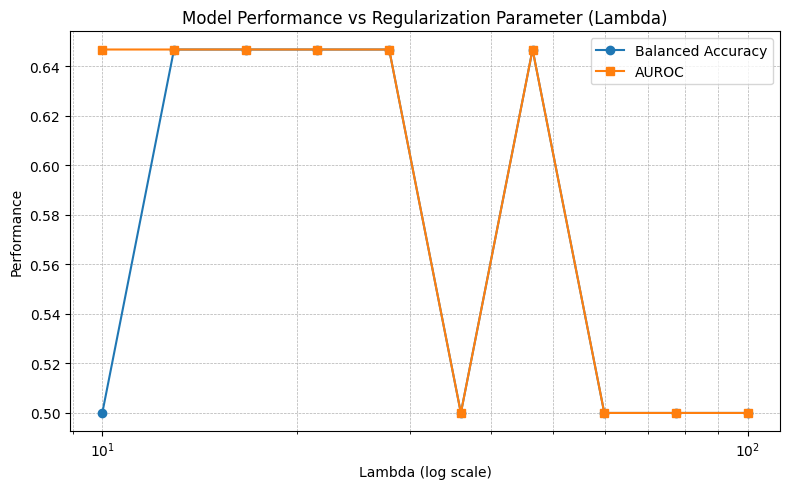

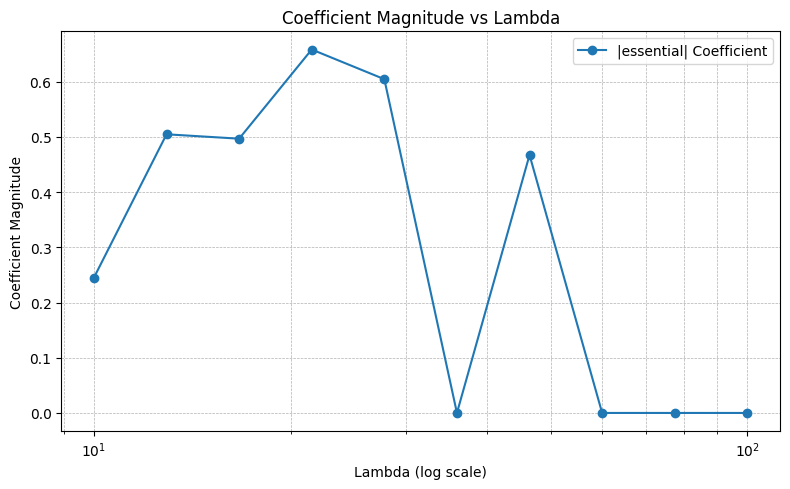

In [13]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, balanced_accuracy_score
import pandas as pd
import matplotlib.pyplot as plt

def train_and_evaluate(final_lambda, X_train, y_train, X_holdout, y_holdout, max_iter=10000, random_seed=1):
    model = LogisticRegression(
        penalty="l1",
        solver="saga",
        max_iter=max_iter,
        C=1 / final_lambda,
        random_state=random_seed,
        class_weight='balanced'
    )
    model.fit(X_train, y_train)
    
    y_prob = model.predict_proba(X_holdout)[:, 1]
    y_pred = model.predict(X_holdout)
    
    auroc = roc_auc_score(y_holdout, y_prob)
    bal_acc = balanced_accuracy_score(y_holdout, y_pred)
    
    coef = model.coef_.flatten()
    nonzero_indices = coef != 0
    nonzero_coefs = coef[nonzero_indices]
    nonzero_features = X_train.columns[nonzero_indices]
    
    # Sort features by descending absolute coefficient magnitude
    sorted_idx = abs(nonzero_coefs).argsort()[::-1]
    sorted_features = nonzero_features[sorted_idx]
    sorted_coefs = nonzero_coefs[sorted_idx]
    
    return {
        'lambda': final_lambda,
        'model': model,
        'auroc': auroc,
        'bal_acc': bal_acc,
        'features': list(zip(sorted_features, sorted_coefs))
    }

# Define lambda values (log spaced between 10 and 100)
lambda_values_to_test = np.logspace(np.log10(10), np.log10(100), num=10)

results_list = []
auroc_vals = []
bal_acc_vals = []

# Collect coef values for plotting
coef_records = {feat: [] for feat in selected_columns.columns if feat in ['essential']}  # adjust features here if needed

for lam in lambda_values_to_test:
    print(f"\nTraining and evaluating model for lambda = {lam:.4f} ...")
    res = train_and_evaluate(lam, X_train, y_train, X_holdout, y_holdout)
    results_list.append(res)
    
    auroc_vals.append(res['auroc'])
    bal_acc_vals.append(res['bal_acc'])
    
    print(f"Holdout AUROC: {res['auroc']:.3f}")
    print(f"Holdout Balanced Accuracy: {res['bal_acc']:.3f}")
    print("Selected Features (coef magnitude desc):")
    for feat, coef in res['features']:
        print(f"  {feat.ljust(26)}: {coef:.5f}")
    
    # Record coefficient for 'essential' if present, else zero
    coef_dict = dict(res['features'])
    for feat in coef_records:
        coef_records[feat].append(abs(coef_dict.get(feat, 0)))

# Plot AUROC and Balanced Accuracy vs Lambda
plt.figure(figsize=(8, 5))
plt.plot(lambda_values_to_test, bal_acc_vals, marker='o', label='Balanced Accuracy')
plt.plot(lambda_values_to_test, auroc_vals, marker='s', label='AUROC')
plt.xscale('log')
plt.xlabel('Lambda (log scale)')
plt.ylabel('Performance')
plt.title('Model Performance vs Regularization Parameter (Lambda)')
plt.legend()
plt.grid(True, which="both", ls="--", linewidth=0.5)
plt.tight_layout()
plt.show()

# Plot Coefficient Magnitude vs Lambda for features of interest
plt.figure(figsize=(8, 5))
for feat, coefs in coef_records.items():
    plt.plot(lambda_values_to_test, coefs, marker='o', label=f'|{feat}| Coefficient')

plt.xscale('log')
plt.xlabel('Lambda (log scale)')
plt.ylabel('Coefficient Magnitude')
plt.title('Coefficient Magnitude vs Lambda')
plt.legend()
plt.grid(True, which="both", ls="--", linewidth=0.5)
plt.tight_layout()
plt.show()
